**Формирование временных окон и сравнение архитектур автоэнкодеров: GRU vs TCN vs Hybrid(TCN-энкодер + GRU-декодер)**

**Цель**: Эмпирический выбор оптимальной архитектуры для сжатия временных окон скважин.

**Этапы**:
1. Формирование скользящих окон (ЭЦН: size_ecn×9, ШГН: size_shgn×9 — размеры из window_sizes.json)
2. Подбор оптимальной размерности латентного пространства (4, 8, 16, 32)
3. Обучение и валидация автоэнкодеров
4. Визуализация качества реконструкции

**Вход**: ../data/processed/X_{ecn,shgn}_{train,val,test}.npy + scaler_*.pkl + window_sizes.json

**Выход**: models/{ecn,shgn}/model.pth + scaler.pkl

In [1]:
import copy
import json
import logging
import pickle
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib.ticker import FormatStrFormatter, MultipleLocator
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

sys.path.insert(0, str(Path("../models").resolve()))
from models import build_model

# ==== КОНФИГУРАЦИЯ И ЦВЕТОВАЯ СХЕМА ====

In [2]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[logging.StreamHandler()],
)
logger = logging.getLogger(__name__)

In [3]:
SEED: int = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.set_float32_matmul_precision("high")

DEVICE: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Устройство: {DEVICE}")

2026-02-25 15:57:57,359 - INFO - Устройство: cuda


In [4]:
ARCH_COLORS: dict[str, str] = {"GRU": "#A23B72", "TCN": "#F18F01", "Hybrid": "#2E86AB"}

plt.rcParams.update(
    {
        "figure.figsize": (15, 6),
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "figure.dpi": 100,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
    }
)

DATA_DIR: Path = Path("../data/processed")
MODELS_DIR: Path = Path("../models")

FEATURE_COLUMNS: list[str] = [
    "us_center",
    "us_periph",
    "gas_center",
    "gas_periph",
    "temp",
    "water_center",
    "water_periph",
    "gas_integral",
    "water_integral",
]

with open(DATA_DIR / "window_sizes.json") as f:
    WINDOW_SIZES: dict[str, int] = json.load(f)

STRIDES: dict[str, int] = {"ecn": 30, "shgn": 25}
LATENT_DIMS: list[int] = [4, 8, 16, 32]

@dataclass
class TrainingConfig:
    input_dim: int
    hidden_size: int
    num_layers: int
    kernel_size: int
    dilation_base: int
    dropout: float
    epochs: int
    batch_size: int
    lr: float
    weight_decay: float
    patience: int
    diff_weight: float
    curvature_weight: float
    contrastive_weight: float
    eta_min: float


CONFIG = TrainingConfig(
    input_dim=len(FEATURE_COLUMNS),
    hidden_size=256,
    num_layers=2,
    kernel_size=5,
    dilation_base=2,
    dropout=0.2,
    epochs=100,
    batch_size=256,
    lr=1e-3,
    weight_decay=1e-5,
    patience=20,
    diff_weight=0.15,
    curvature_weight=0.05,
    contrastive_weight=0.02,
    eta_min=1e-6,
)

# ==== 1. ЗАГРУЗКА ДАННЫХ И ФОРМИРОВАНИЕ ОКОН ====

In [6]:
def _windows_from_array(X: np.ndarray, window_size: int, stride: int) -> np.ndarray:
    if len(X) < window_size:
        return np.empty((0, window_size, len(FEATURE_COLUMNS)), dtype=np.float32)
    w = sliding_window_view(X, window_shape=window_size, axis=0)[::stride]
    return np.transpose(w, (0, 2, 1)).astype(np.float32)

In [7]:
def load_and_create_windows(
    prefix: str,
    window_size: int,
    train_stride: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, StandardScaler]:
    X_train: np.ndarray = np.load(DATA_DIR / f"X_{prefix}_train.npy")
    X_val: np.ndarray = np.load(DATA_DIR / f"X_{prefix}_val.npy")
    X_test: np.ndarray = np.load(DATA_DIR / f"X_{prefix}_test.npy")

    with open(DATA_DIR / f"scaler_{prefix}.pkl", "rb") as f:
        scaler: StandardScaler = pickle.load(f)

    train = _windows_from_array(X_train, window_size, train_stride)
    val = _windows_from_array(X_val, window_size, 1)
    test = _windows_from_array(X_test, window_size, 1)

    logger.info(f"{prefix.upper()}: train={train.shape} | val={val.shape} | test={test.shape}")
    return train, val, test, scaler

In [8]:
X_ecn_train, X_ecn_val, X_ecn_test, scaler_ecn = load_and_create_windows(
    "ecn", window_size=WINDOW_SIZES["ecn"], train_stride=STRIDES["ecn"]
)
X_shgn_train, X_shgn_val, X_shgn_test, scaler_shgn = load_and_create_windows(
    "shgn", window_size=WINDOW_SIZES["shgn"], train_stride=STRIDES["shgn"]
)

2026-02-25 15:58:06,526 - INFO - ECN: train=(962, 120, 9) | val=(6086, 120, 9) | test=(6087, 120, 9)


2026-02-25 15:58:06,571 - INFO - SHGN: train=(3508, 100, 9) | val=(18715, 100, 9) | test=(18715, 100, 9)


In [9]:
def plot_random_window(X: np.ndarray, pump_type: str, color: str) -> None:
    idx: int = int(np.random.randint(0, len(X)))
    window: np.ndarray = X[idx]
    fig, axes = plt.subplots(3, 3, figsize=(16, 10))
    for i, (ax, feature) in enumerate(zip(axes.flatten(), FEATURE_COLUMNS, strict=True)):
        ax.plot(window[:, i], color=color, linewidth=2, alpha=0.9)
        ax.set_title(feature, fontsize=11, fontweight="bold")
        ax.set_xlabel("Время (×10 сек)", fontsize=9)
    fig.suptitle(
        f"{pump_type}: окно #{idx} ({window.shape[0]} точек = {window.shape[0] * 10 / 60:.1f} мин)",
        fontsize=14,
        fontweight="bold",
        y=1.01,
    )
    plt.tight_layout()
    plt.show()
    plt.close(fig)

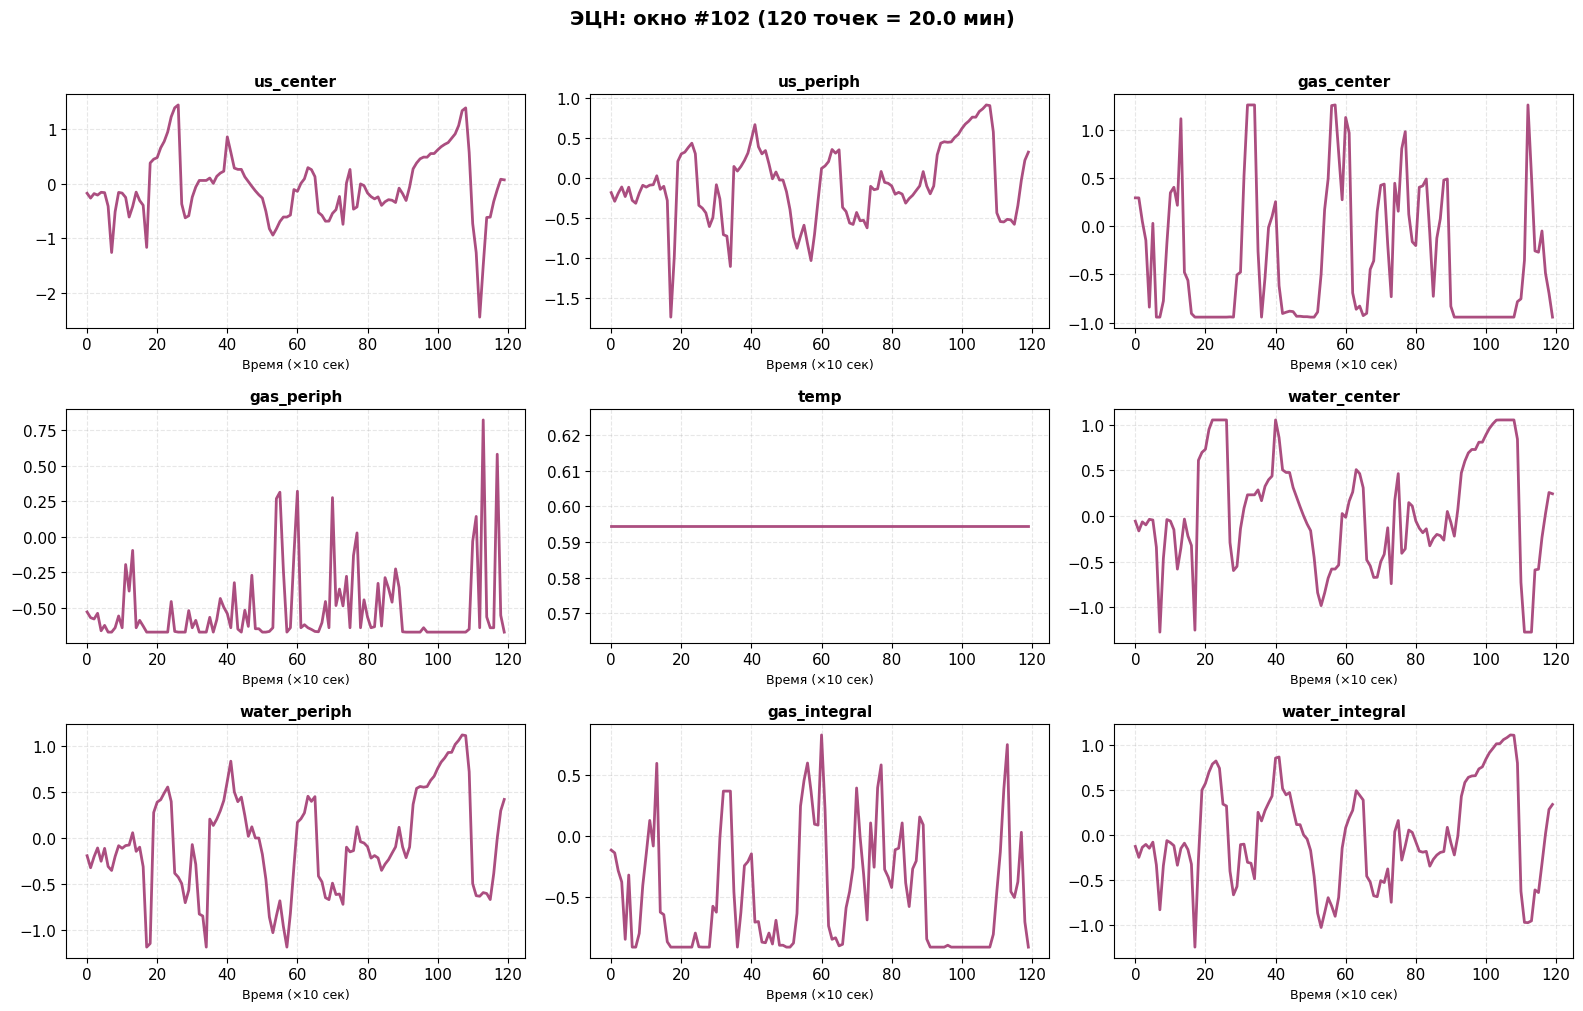

In [10]:
plot_random_window(X_ecn_train, "ЭЦН", ARCH_COLORS["GRU"])

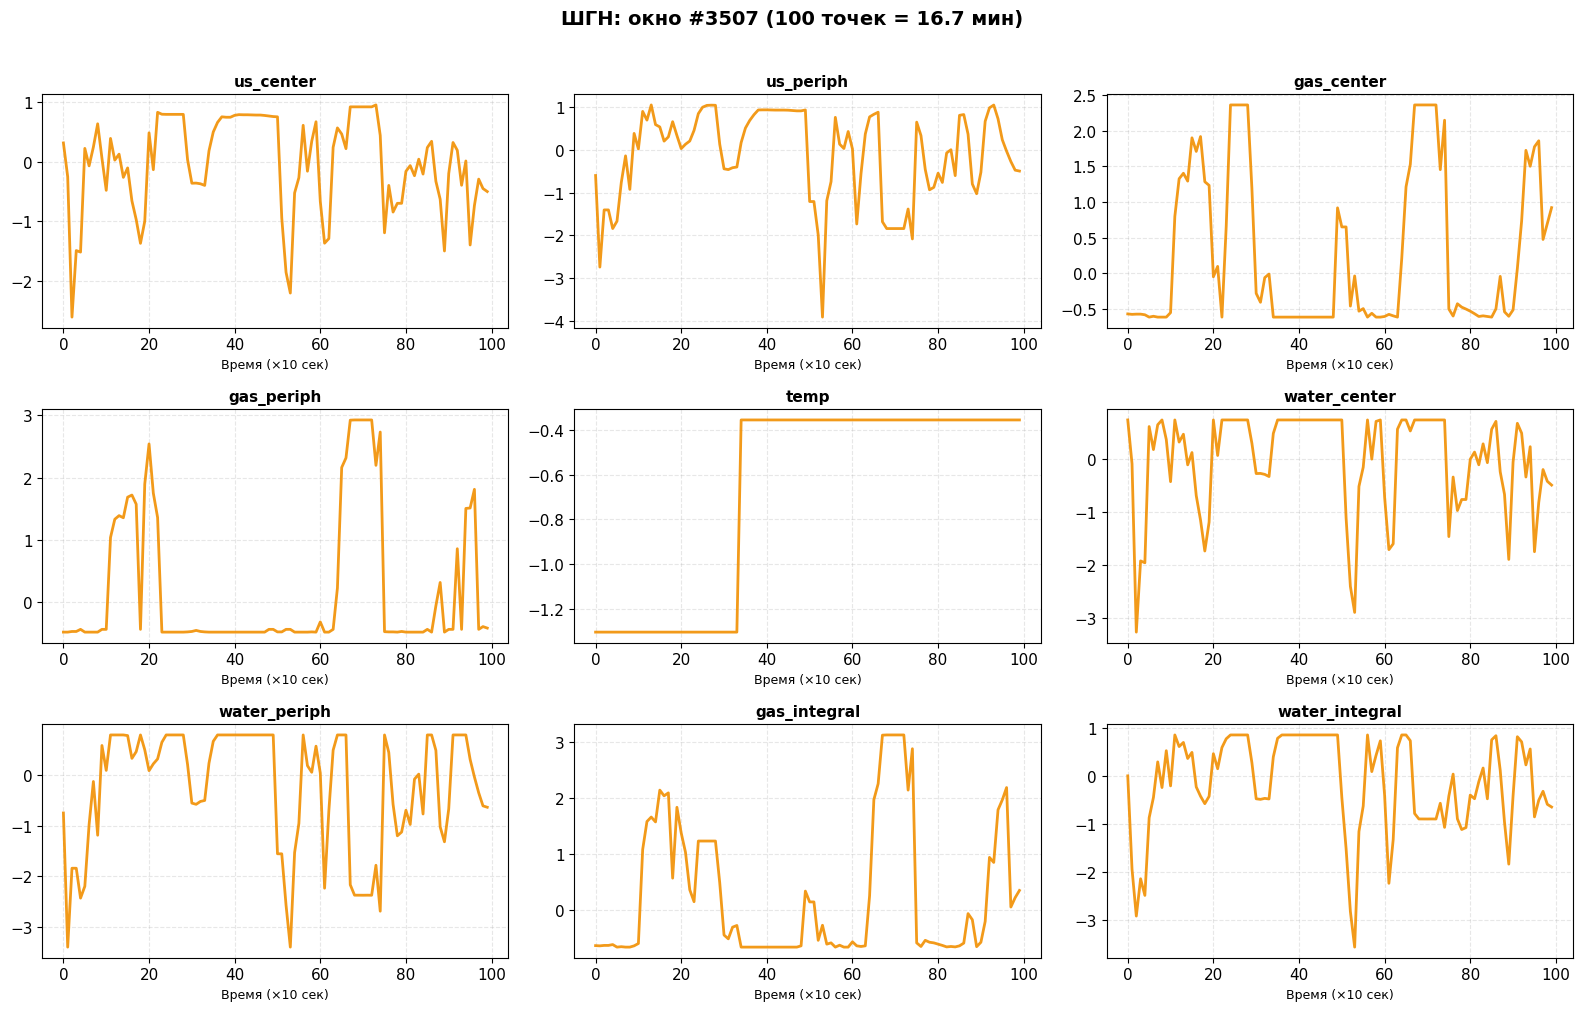

In [11]:
plot_random_window(X_shgn_train, "ШГН", ARCH_COLORS["TCN"])

#  ==== 2. ОБУЧЕНИЕ И ВАЛИДАЦИЯ ====

In [12]:
@dataclass
class ArchConfig:
    name: str
    color: str

    def make_model(self, latent_dim: int, dropout: float) -> nn.Module:
        return build_model(
            self.name,
            CONFIG.input_dim,
            CONFIG.hidden_size,
            latent_dim,
            CONFIG.num_layers,
            CONFIG.kernel_size,
            CONFIG.dilation_base,
            dropout,
        )


def _make_arch_configs() -> list[ArchConfig]:
    return [ArchConfig(name=name, color=ARCH_COLORS[name]) for name in ("GRU", "TCN", "Hybrid")]

In [ ]:
def _compute_loss(
    recon: torch.Tensor,
    target: torch.Tensor,
    z: torch.Tensor,
    z_pos: torch.Tensor,
    config: TrainingConfig,
) -> torch.Tensor:
    huber = F.huber_loss(recon, target, delta=0.5)

    diff_loss = F.mse_loss(recon[:, 1:] - recon[:, :-1], target[:, 1:] - target[:, :-1])

    d2_recon = recon[:, 2:] - 2 * recon[:, 1:-1] + recon[:, :-2]
    d2_target = target[:, 2:] - 2 * target[:, 1:-1] + target[:, :-2]
    curvature_loss = F.mse_loss(d2_recon, d2_target)

    pos_dist = F.pairwise_distance(z, z_pos, p=2)

    bs = z.size(0)
    idx = (torch.arange(bs, device=z.device) + 1) % bs
    z_neg = z[idx]
    neg_dist = F.pairwise_distance(z, z_neg, p=2)

    loss_pos = pos_dist.mean()
    loss_neg = F.relu(0.5 - neg_dist).mean()
    contrastive_loss = loss_pos + loss_neg

    return (
        huber
        + config.diff_weight * diff_loss
        + config.curvature_weight * curvature_loss
        + config.contrastive_weight * contrastive_loss
    )

In [14]:
def _run_epoch(
    model: nn.Module,
    loader: DataLoader,
    config: TrainingConfig,
    optimizer: torch.optim.Optimizer | None = None,
) -> tuple[float, float]:
    is_train = optimizer is not None
    model.train(is_train)
    total_loss: float = 0.0
    total_mae: float = 0.0
    n: float = 0.0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for (x,) in loader:
            x = x.to(DEVICE)
            x_aug = x + torch.randn_like(x) * 0.05

            recon, z = model(x)
            _, z_pos = model(x_aug)

            loss = _compute_loss(recon, x, z, z_pos, config)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            bs = x.size(0)
            total_loss += loss.item() * bs
            total_mae += F.l1_loss(recon.detach(), x).item() * bs
            n += bs

    return total_loss / n, total_mae / n

In [15]:
@dataclass
class TrainResult:
    val_loss: float
    val_mae: float
    test_loss: float
    test_mae: float
    history: dict[str, list[float]]
    state_dict: dict[str, torch.Tensor]
    latent_dim: int


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader,
    config: TrainingConfig,
    latent_dim: int,
) -> TrainResult:
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.epochs, eta_min=config.eta_min)

    best_val: float = float("inf")
    best_state: dict[str, torch.Tensor] | None = None
    patience: int = 0
    history: dict[str, list[float]] = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}

    for _ in tqdm(range(config.epochs), desc="Обучение", unit="epoch", leave=False):
        tl, tm = _run_epoch(model, train_loader, config, optimizer)
        vl, vm = _run_epoch(model, val_loader, config)
        scheduler.step()

        history["train_loss"].append(tl)
        history["train_mae"].append(tm)
        history["val_loss"].append(vl)
        history["val_mae"].append(vm)

        if vl < best_val:
            best_val = vl
            best_state = copy.deepcopy(model.state_dict())
            patience = 0
        else:
            patience += 1
            if patience >= config.patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_loss, test_mae = _run_epoch(model, test_loader, config)
    best_epoch: int = int(np.argmin(history["val_loss"]))

    return TrainResult(
        val_loss=best_val,
        val_mae=history["val_mae"][best_epoch],
        test_loss=test_loss,
        test_mae=test_mae,
        history=history,
        state_dict=copy.deepcopy(model.state_dict()),
        latent_dim=latent_dim,
    )

In [16]:
def _make_loaders(
    X_train: np.ndarray,
    X_val: np.ndarray,
    X_test: np.ndarray,
    config: TrainingConfig,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    pin: bool = torch.cuda.is_available()

    def _loader(X: np.ndarray, shuffle: bool) -> DataLoader:
        return DataLoader(
            TensorDataset(torch.from_numpy(X).float()),
            batch_size=config.batch_size,
            shuffle=shuffle,
            drop_last=shuffle,
            num_workers=0,
            pin_memory=pin,
        )

    return _loader(X_train, True), _loader(X_val, False), _loader(X_test, False)

In [17]:
@dataclass
class ArchResult:
    best: TrainResult
    all_dims: list[TrainResult]
    color: str


def train_all_architectures(
    X_train: np.ndarray,
    X_val: np.ndarray,
    X_test: np.ndarray,
    pump_type: str,
    config: TrainingConfig,
) -> dict[str, ArchResult]:
    train_loader, val_loader, test_loader = _make_loaders(X_train, X_val, X_test, config)
    all_results: dict[str, ArchResult] = {}

    for arch in _make_arch_configs():
        logger.info(f"[{pump_type}] Архитектура: {arch.name}")
        best_result: TrainResult | None = None
        dim_results: list[TrainResult] = []

        for latent_dim in LATENT_DIMS:
            torch.manual_seed(SEED)
            model = arch.make_model(latent_dim, config.dropout).to(DEVICE)
            result = train_model(model, train_loader, val_loader, test_loader, config, latent_dim)
            del model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            dim_results.append(result)
            if best_result is None or result.val_loss < best_result.val_loss:
                best_result = result

            logger.info(f"  latent_dim={latent_dim} | val_loss={result.val_loss:.5f} | val_mae={result.val_mae:.5f}")

        assert best_result is not None
        all_results[arch.name] = ArchResult(best=best_result, all_dims=dim_results, color=arch.color)

    return all_results

# ==== 3. ВИЗУАЛИЗАЦИЯ ====

In [18]:
def print_summary_table(results: dict[str, ArchResult], pump_type: str) -> None:
    rows: list[dict[str, float | int | str]] = []
    best_per_arch: dict[str, int] = {name: r.best.latent_dim for name, r in results.items()}

    for name, arch_res in results.items():
        for entry in arch_res.all_dims:
            rows.append(
                {
                    "Архитектура": name,
                    "latent_dim": entry.latent_dim,
                    "val_loss": entry.val_loss,
                    "val_mae": entry.val_mae,
                    "test_loss": entry.test_loss,
                    "test_mae": entry.test_mae,
                }
            )

    df = pd.DataFrame(rows)

    def _highlight(row: pd.Series) -> list[str]:
        is_best = row["latent_dim"] == best_per_arch[row["Архитектура"]]
        color = "background-color: #d4edda; font-weight: bold" if is_best else ""
        return [color] * len(row)

    styled = (
        df.style.apply(_highlight, axis=1)
        .format({"val_loss": "{:.5f}", "val_mae": "{:.5f}", "test_loss": "{:.5f}", "test_mae": "{:.5f}"})
        .set_caption(f"{pump_type} — сводная таблица результатов")
        .set_table_styles([{"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]}])
    )
    display(styled)

In [19]:
def plot_training_curves(results: dict[str, ArchResult], pump_type: str) -> None:
    fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
    for ax, (name, r) in zip(axes, results.items(), strict=True):
        h = r.best.history
        ax.plot(h["train_loss"], color=r.color, linewidth=2, label="Train")
        ax.plot(h["val_loss"], color=r.color, linewidth=2, linestyle="--", label="Val")
        ax.set_title(f"{name}\nVal MSE={r.best.val_loss:.4f}")
        ax.set_xlabel("Эпохи")
        ax.set_ylabel("Loss")
        ax.legend()
        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.xaxis.set_major_formatter(FormatStrFormatter("%d"))
    fig.suptitle(f"{pump_type}: кривые обучения", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [20]:
def plot_reconstruction(
    model: nn.Module,
    X_val: np.ndarray,
    arch_name: str,
    pump_type: str,
    idx: int,
) -> None:
    model.eval()
    with torch.no_grad():
        x = torch.from_numpy(X_val[idx]).float().unsqueeze(0).to(DEVICE)
        recon, _ = model(x)
        mse = F.mse_loss(recon, x).item()
        mae = F.l1_loss(recon, x).item()

    x_np = x[0].cpu().numpy()
    r_np = recon[0].cpu().numpy()
    steps = np.arange(X_val.shape[1])

    fig, axes = plt.subplots(3, 3, figsize=(20, 11))
    for i, (ax, feature) in enumerate(zip(axes.flatten(), FEATURE_COLUMNS, strict=True)):
        ax.plot(steps, x_np[:, i], color="#1f77b4", linewidth=2, label="Input")
        ax.plot(steps, r_np[:, i], color="#d62728", linewidth=1.5, label="Recon")
        ax.fill_between(steps, x_np[:, i], r_np[:, i], color="#ff9896", alpha=0.4)
        ax.set_title(feature, fontsize=11, fontweight="bold")
    handles, labels = axes.flatten()[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.99, 0.99))
    fig.suptitle(
        f"{pump_type} | {arch_name} | окно #{idx} ({X_val.shape[1] * 10 / 60:.1f} мин) | MSE={mse:.5f} MAE={mae:.4f}",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()
    plt.close(fig)

In [21]:
def plot_all_reconstructions(results: dict[str, ArchResult], X_val: np.ndarray, pump_type: str) -> None:
    idx: int = int(np.random.randint(0, len(X_val)))
    for arch in _make_arch_configs():
        best = results[arch.name].best
        model = arch.make_model(best.latent_dim, CONFIG.dropout).to(DEVICE)
        model.load_state_dict(best.state_dict)
        plot_reconstruction(model, X_val, arch.name, pump_type, idx)
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

# ==== 4. СРАВНЕНИЕ ДЛЯ ЭЦН ====

In [22]:
ecn_results = train_all_architectures(X_ecn_train, X_ecn_val, X_ecn_test, "ЭЦН", CONFIG)

2026-02-25 15:58:19,367 - INFO - [ЭЦН] Архитектура: GRU
2026-02-25 16:00:57,651 - INFO -   latent_dim=4 | val_loss=0.02359 | val_mae=0.06473
2026-02-25 16:03:34,387 - INFO -   latent_dim=8 | val_loss=0.02347 | val_mae=0.06309
2026-02-25 16:06:13,147 - INFO -   latent_dim=16 | val_loss=0.02348 | val_mae=0.06460
2026-02-25 16:08:54,123 - INFO -   latent_dim=32 | val_loss=0.02337 | val_mae=0.06276
2026-02-25 16:08:54,124 - INFO - [ЭЦН] Архитектура: TCN
2026-02-25 16:11:18,554 - INFO -   latent_dim=4 | val_loss=0.02466 | val_mae=0.07145
2026-02-25 16:13:50,925 - INFO -   latent_dim=8 | val_loss=0.02484 | val_mae=0.07491
2026-02-25 16:16:22,341 - INFO -   latent_dim=16 | val_loss=0.02402 | val_mae=0.06918
2026-02-25 16:18:53,511 - INFO -   latent_dim=32 | val_loss=0.02378 | val_mae=0.06687
2026-02-25 16:18:53,512 - INFO - [ЭЦН] Архитектура: Hybrid
2026-02-25 16:21:02,988 - INFO -   latent_dim=4 | val_loss=0.02367 | val_mae=0.06389
2026-02-25 16:23:15,197 - INFO -   latent_dim=8 | val_loss=0

In [23]:
print_summary_table(ecn_results, "ЭЦН")

,Архитектура,latent_dim,val_loss,val_mae,test_loss,test_mae
0,GRU,4,0.02359,0.06473,0.02654,0.07797
1,GRU,8,0.02347,0.06309,0.02649,0.07745
2,GRU,16,0.02348,0.06460,0.02643,0.07811
3,GRU,32,0.02337,0.06276,0.02621,0.07522
4,TCN,4,0.02466,0.07145,0.02694,0.08046
5,TCN,8,0.02484,0.07491,0.02667,0.08054
6,TCN,16,0.02402,0.06918,0.02621,0.07808
7,TCN,32,0.02378,0.06687,0.02611,0.07563
8,Hybrid,4,0.02367,0.06389,0.02673,0.07860
9,Hybrid,8,0.02357,0.06287,0.02670,0.07743


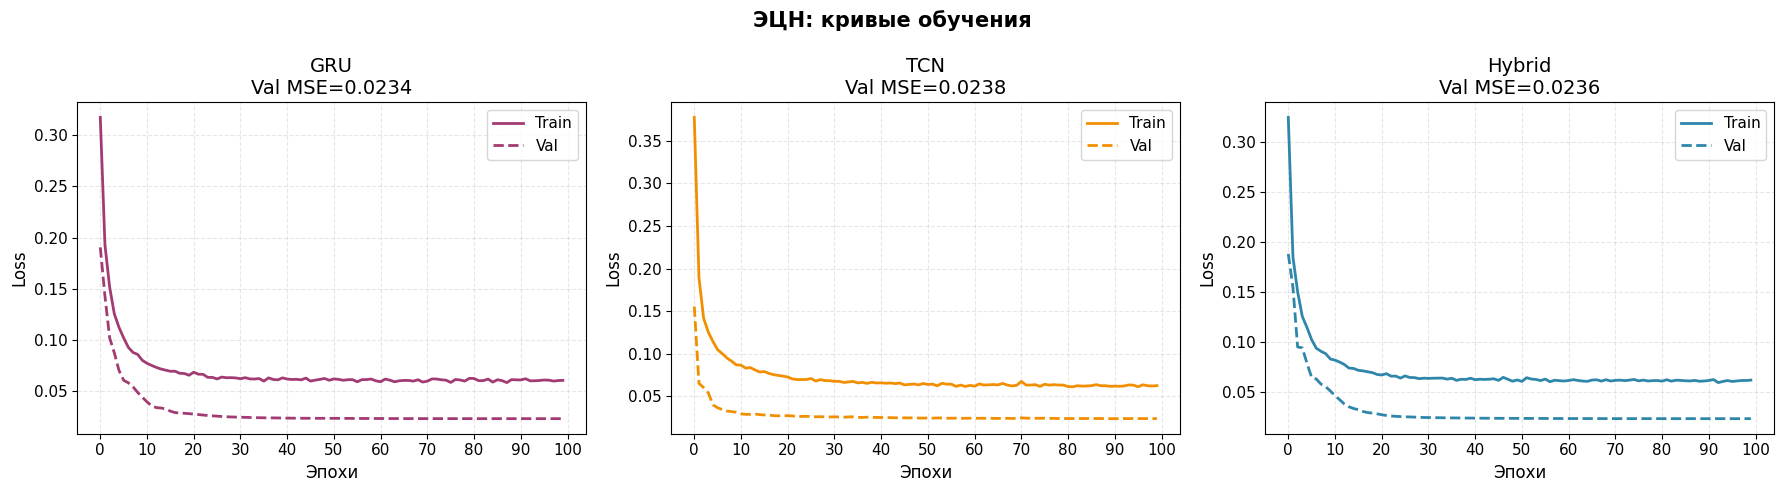

In [24]:
plot_training_curves(ecn_results, "ЭЦН")

2026-02-25 16:28:32,240 - INFO - ЭЦН: лучшая архитектура → GRU


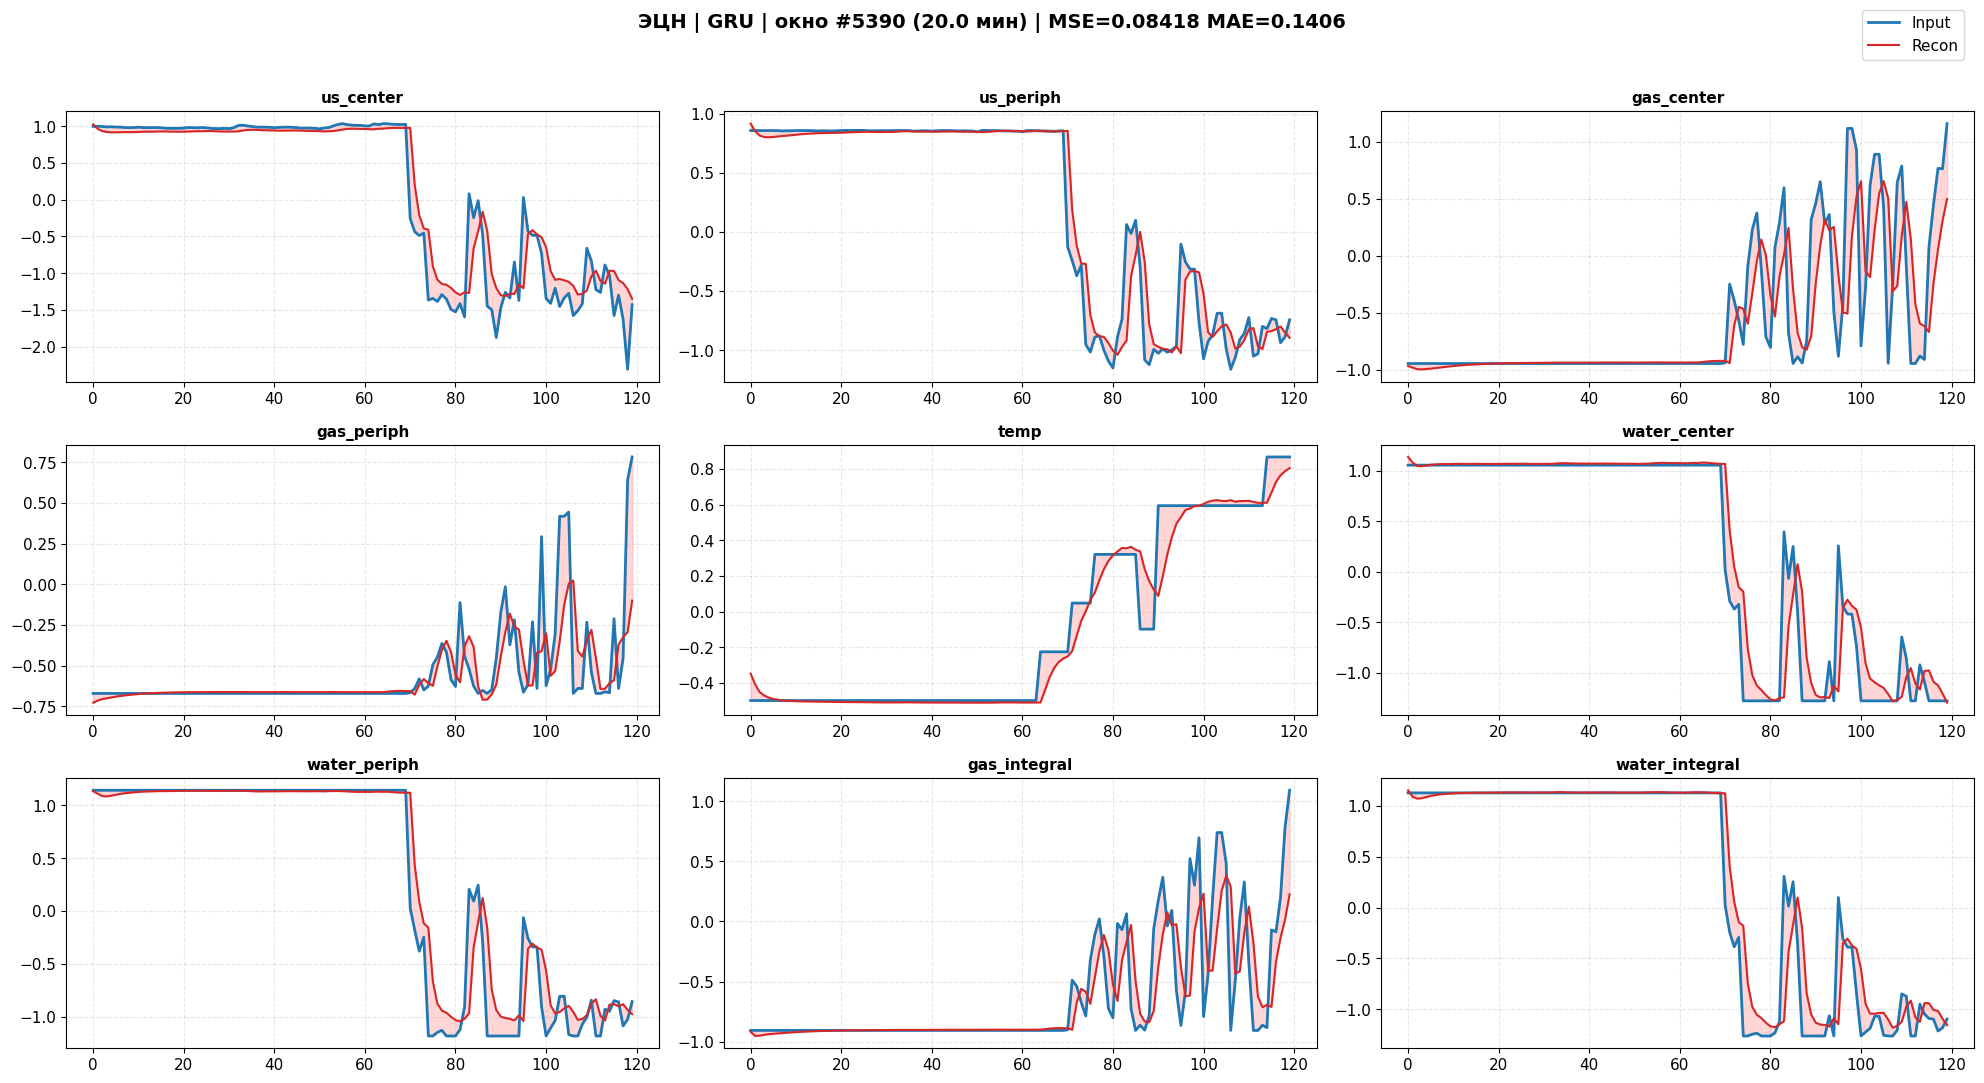

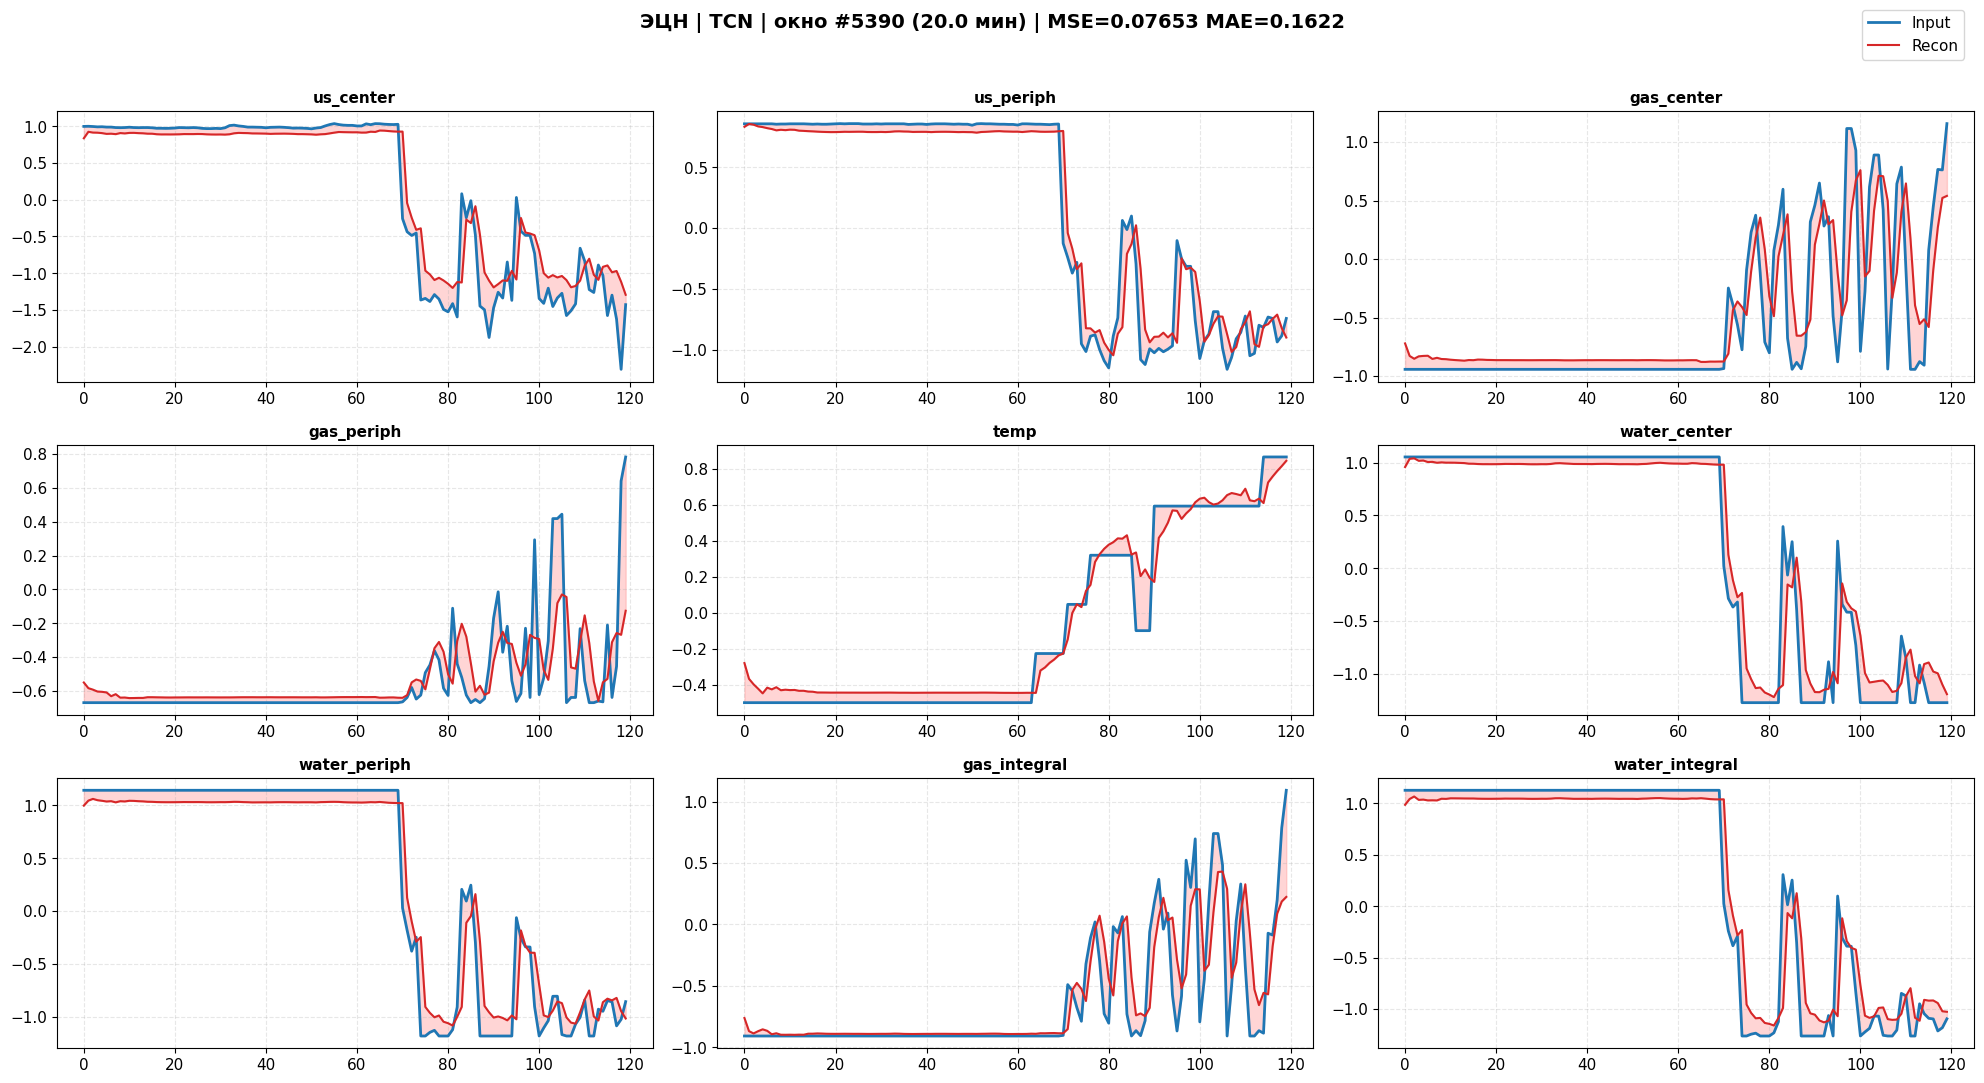

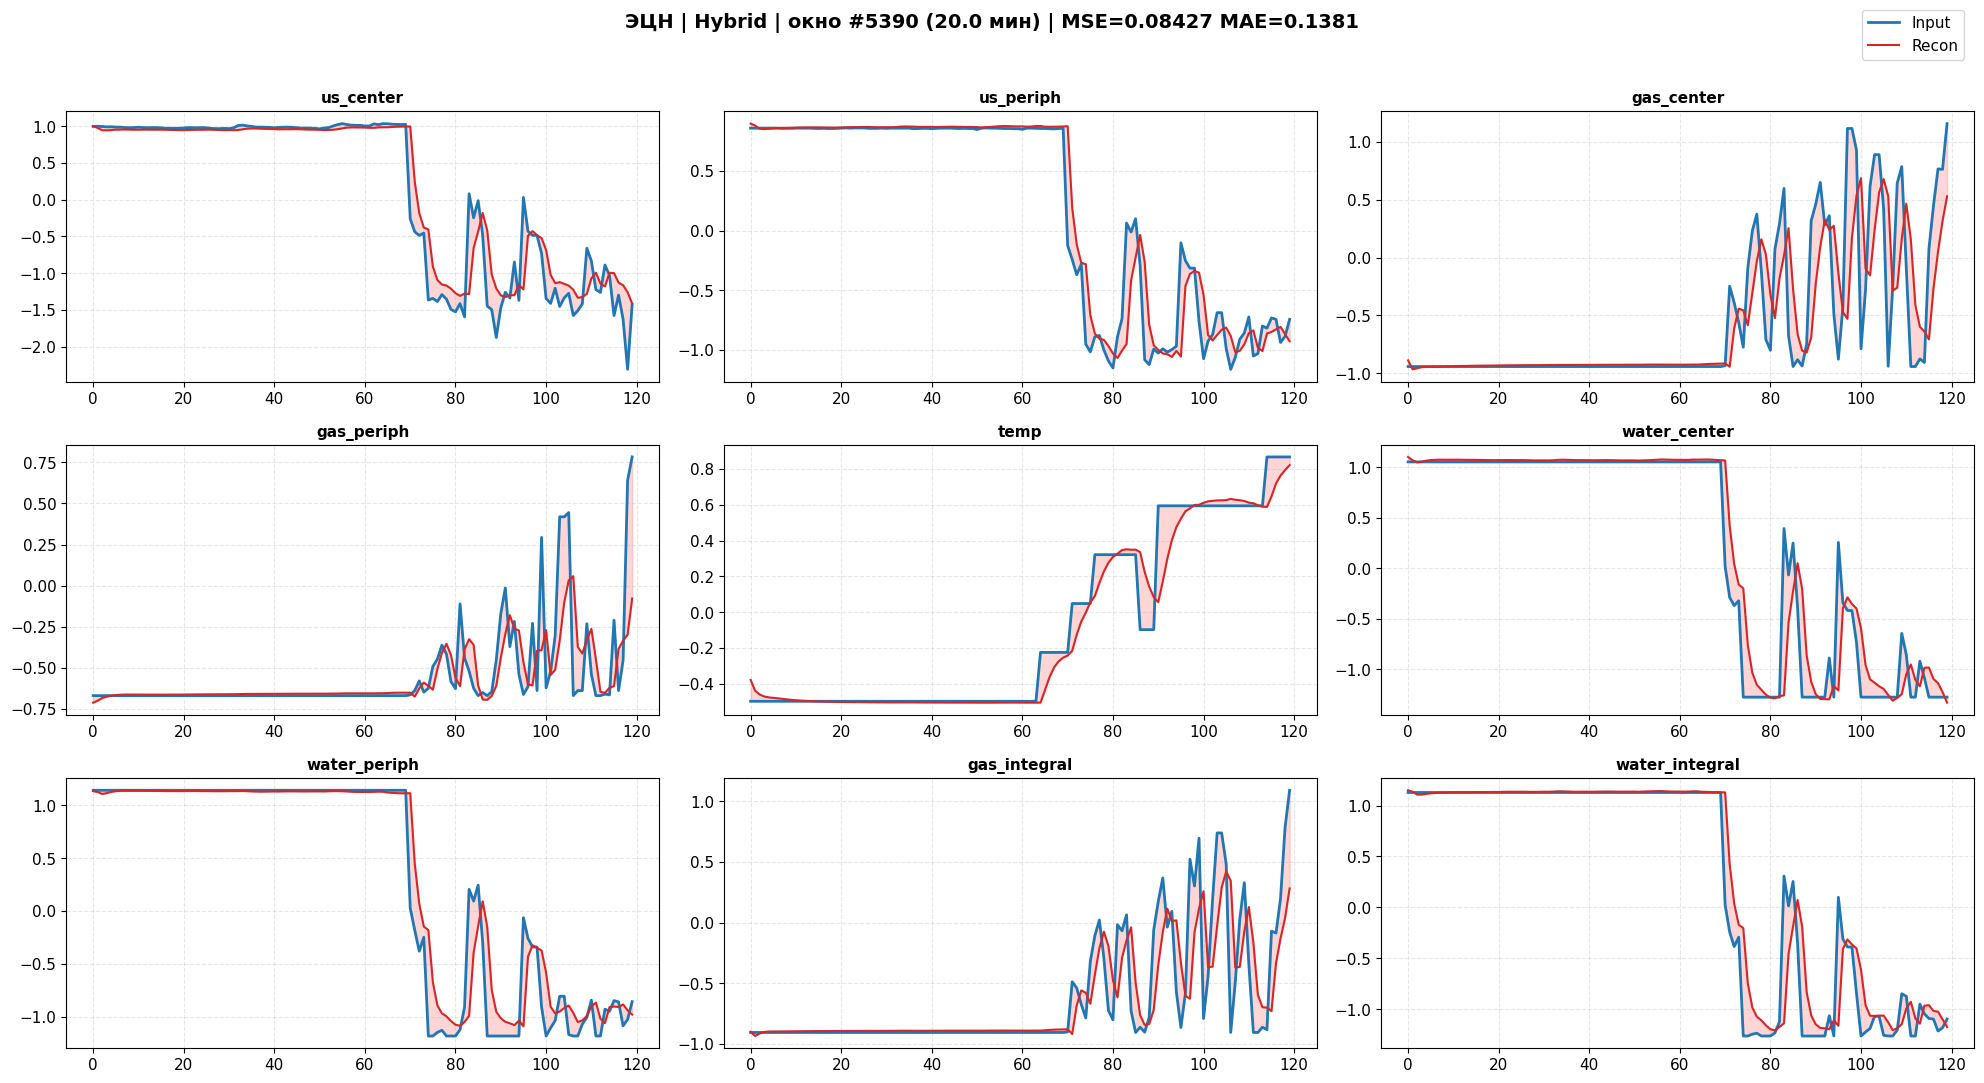

In [26]:
ecn_best_arch: str = min(ecn_results, key=lambda name: ecn_results[name].best.val_loss)
logger.info(f"ЭЦН: лучшая архитектура → {ecn_best_arch}")
plot_all_reconstructions(ecn_results, X_ecn_val, "ЭЦН")

# ==== 5. СРАВНЕНИЕ ДЛЯ ШГН ====

In [29]:
shgn_results = train_all_architectures(X_shgn_train, X_shgn_val, X_shgn_test, "ШГН", CONFIG)

2026-02-25 16:29:33,119 - INFO - [ШГН] Архитектура: GRU
2026-02-25 16:33:41,174 - INFO -   latent_dim=4 | val_loss=0.39000 | val_mae=0.53275
2026-02-25 16:39:07,523 - INFO -   latent_dim=8 | val_loss=0.39194 | val_mae=0.54650
2026-02-25 16:44:09,380 - INFO -   latent_dim=16 | val_loss=0.38543 | val_mae=0.53425
2026-02-25 16:50:28,863 - INFO -   latent_dim=32 | val_loss=0.37572 | val_mae=0.53656
2026-02-25 16:50:28,864 - INFO - [ШГН] Архитектура: TCN
2026-02-25 16:53:21,542 - INFO -   latent_dim=4 | val_loss=0.38966 | val_mae=0.51571
2026-02-25 16:56:36,018 - INFO -   latent_dim=8 | val_loss=0.38750 | val_mae=0.51325
2026-02-25 16:59:54,700 - INFO -   latent_dim=16 | val_loss=0.38527 | val_mae=0.49488
2026-02-25 17:03:09,139 - INFO -   latent_dim=32 | val_loss=0.38734 | val_mae=0.50150
2026-02-25 17:03:09,140 - INFO - [ШГН] Архитектура: Hybrid
2026-02-25 17:07:32,573 - INFO -   latent_dim=4 | val_loss=0.38751 | val_mae=0.53964
2026-02-25 17:12:00,019 - INFO -   latent_dim=8 | val_loss=0

In [30]:
print_summary_table(shgn_results, "ШГН")

,Архитектура,latent_dim,val_loss,val_mae,test_loss,test_mae
0,GRU,4,0.39000,0.53275,0.44367,0.58681
1,GRU,8,0.39194,0.54650,0.45727,0.61906
2,GRU,16,0.38543,0.53425,0.44250,0.59823
3,GRU,32,0.37572,0.53656,0.43624,0.60378
4,TCN,4,0.38966,0.51571,0.43701,0.55439
5,TCN,8,0.38750,0.51325,0.43721,0.55127
6,TCN,16,0.38527,0.49488,0.43340,0.53052
7,TCN,32,0.38734,0.50150,0.43350,0.54059
8,Hybrid,4,0.38751,0.53964,0.44194,0.59847
9,Hybrid,8,0.39042,0.54709,0.44597,0.60727


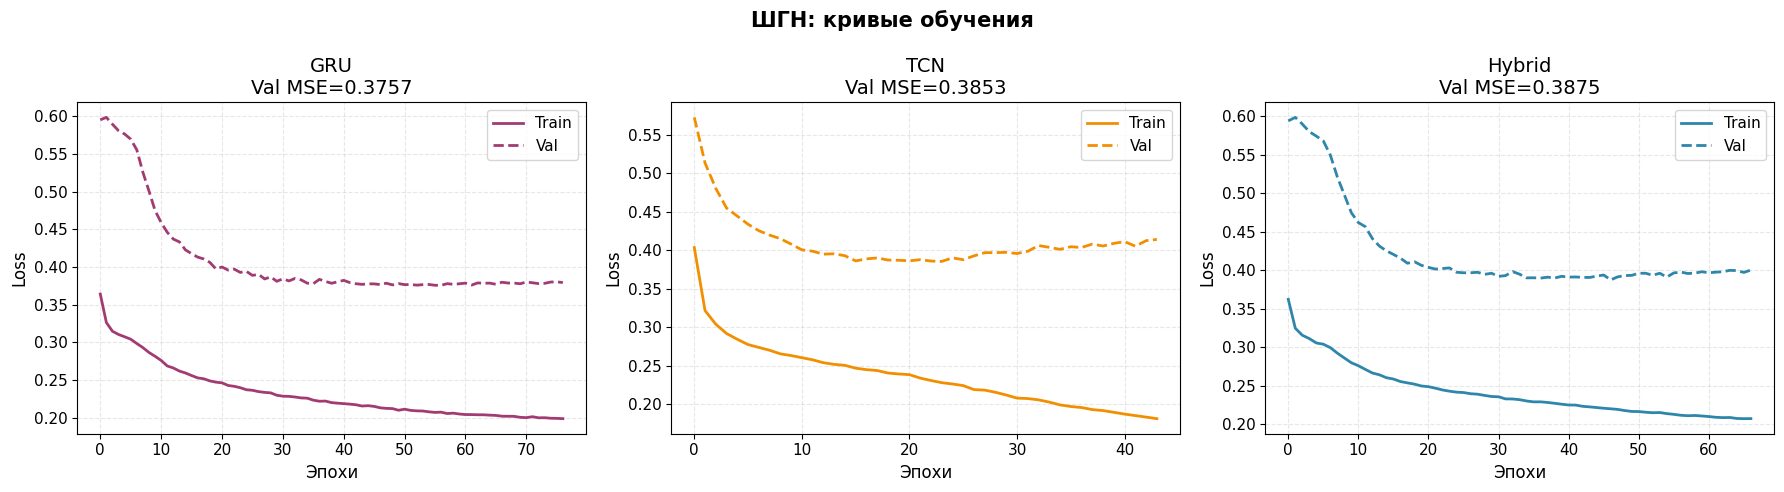

In [31]:
plot_training_curves(shgn_results, "ШГН")

2026-02-25 17:22:58,917 - INFO - ШГН: лучшая архитектура → GRU


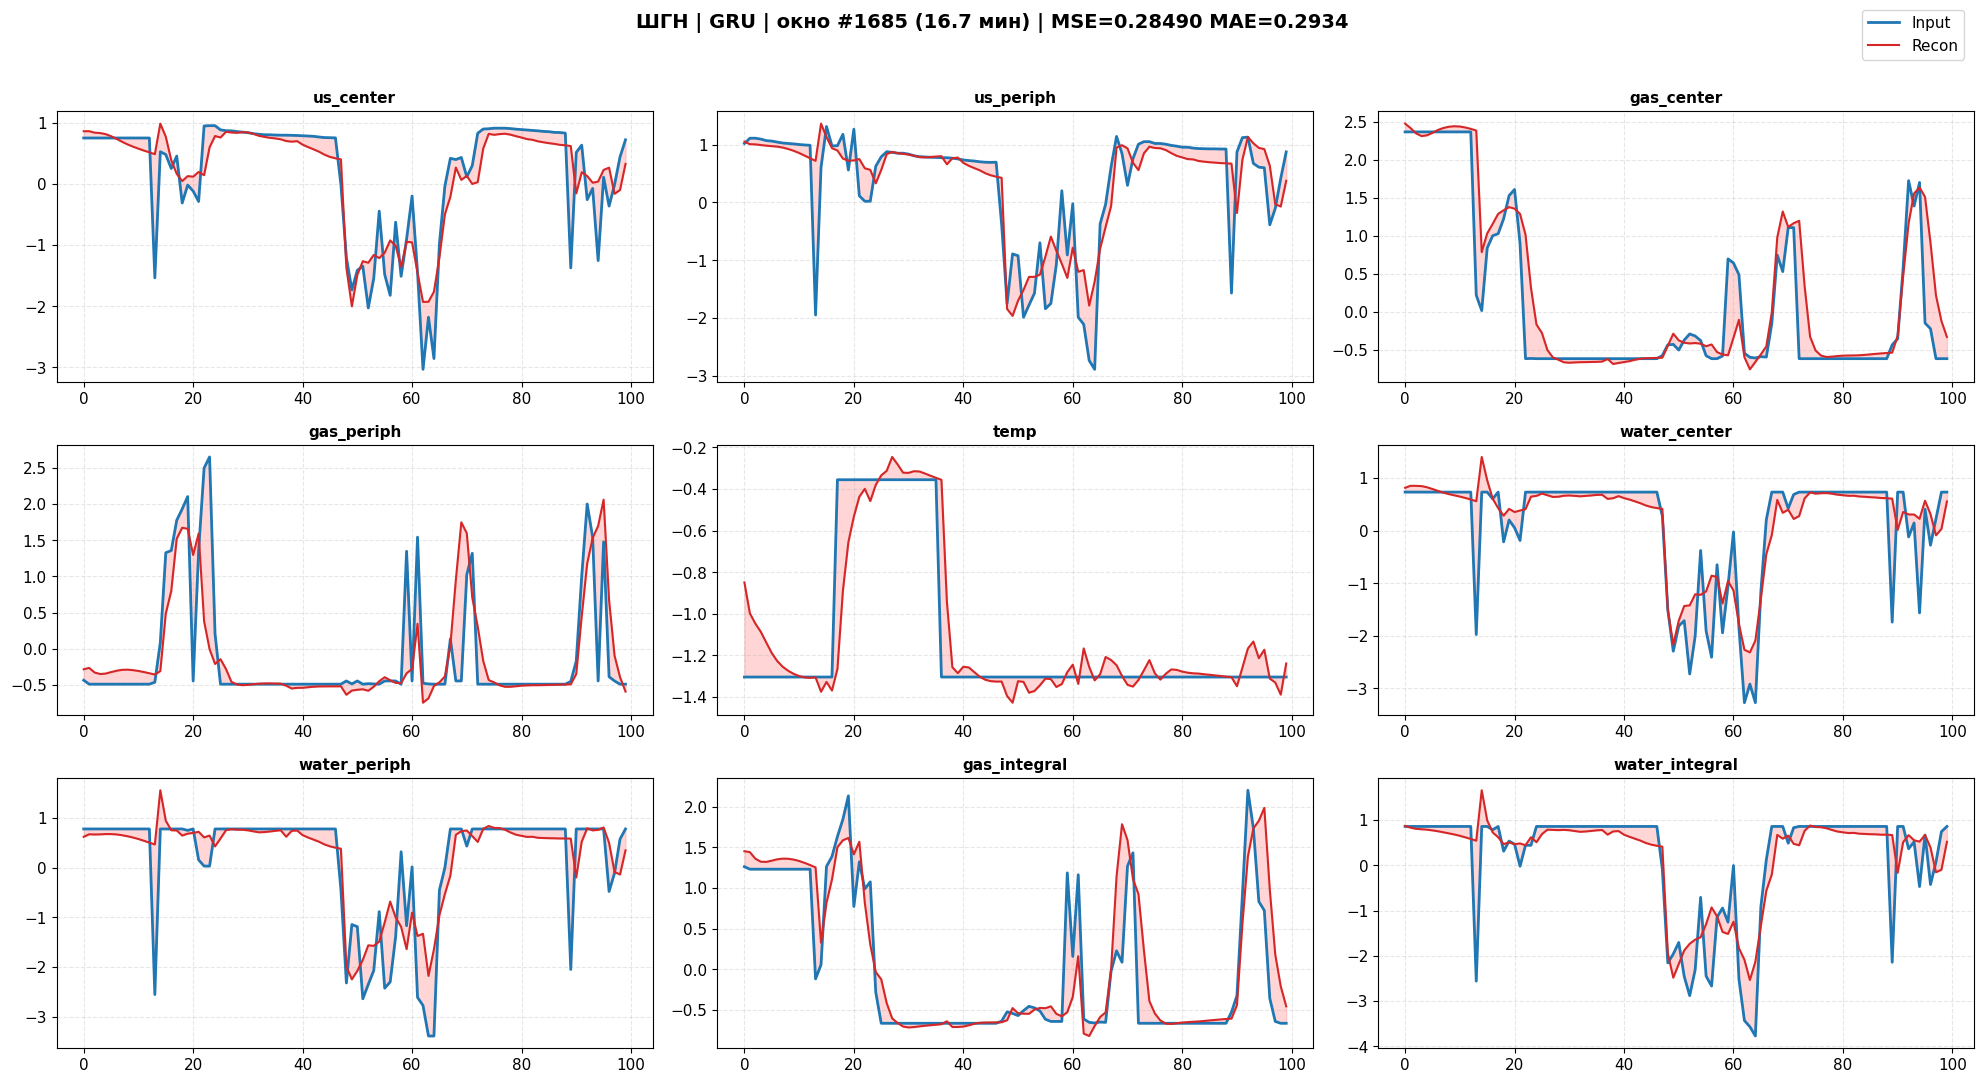

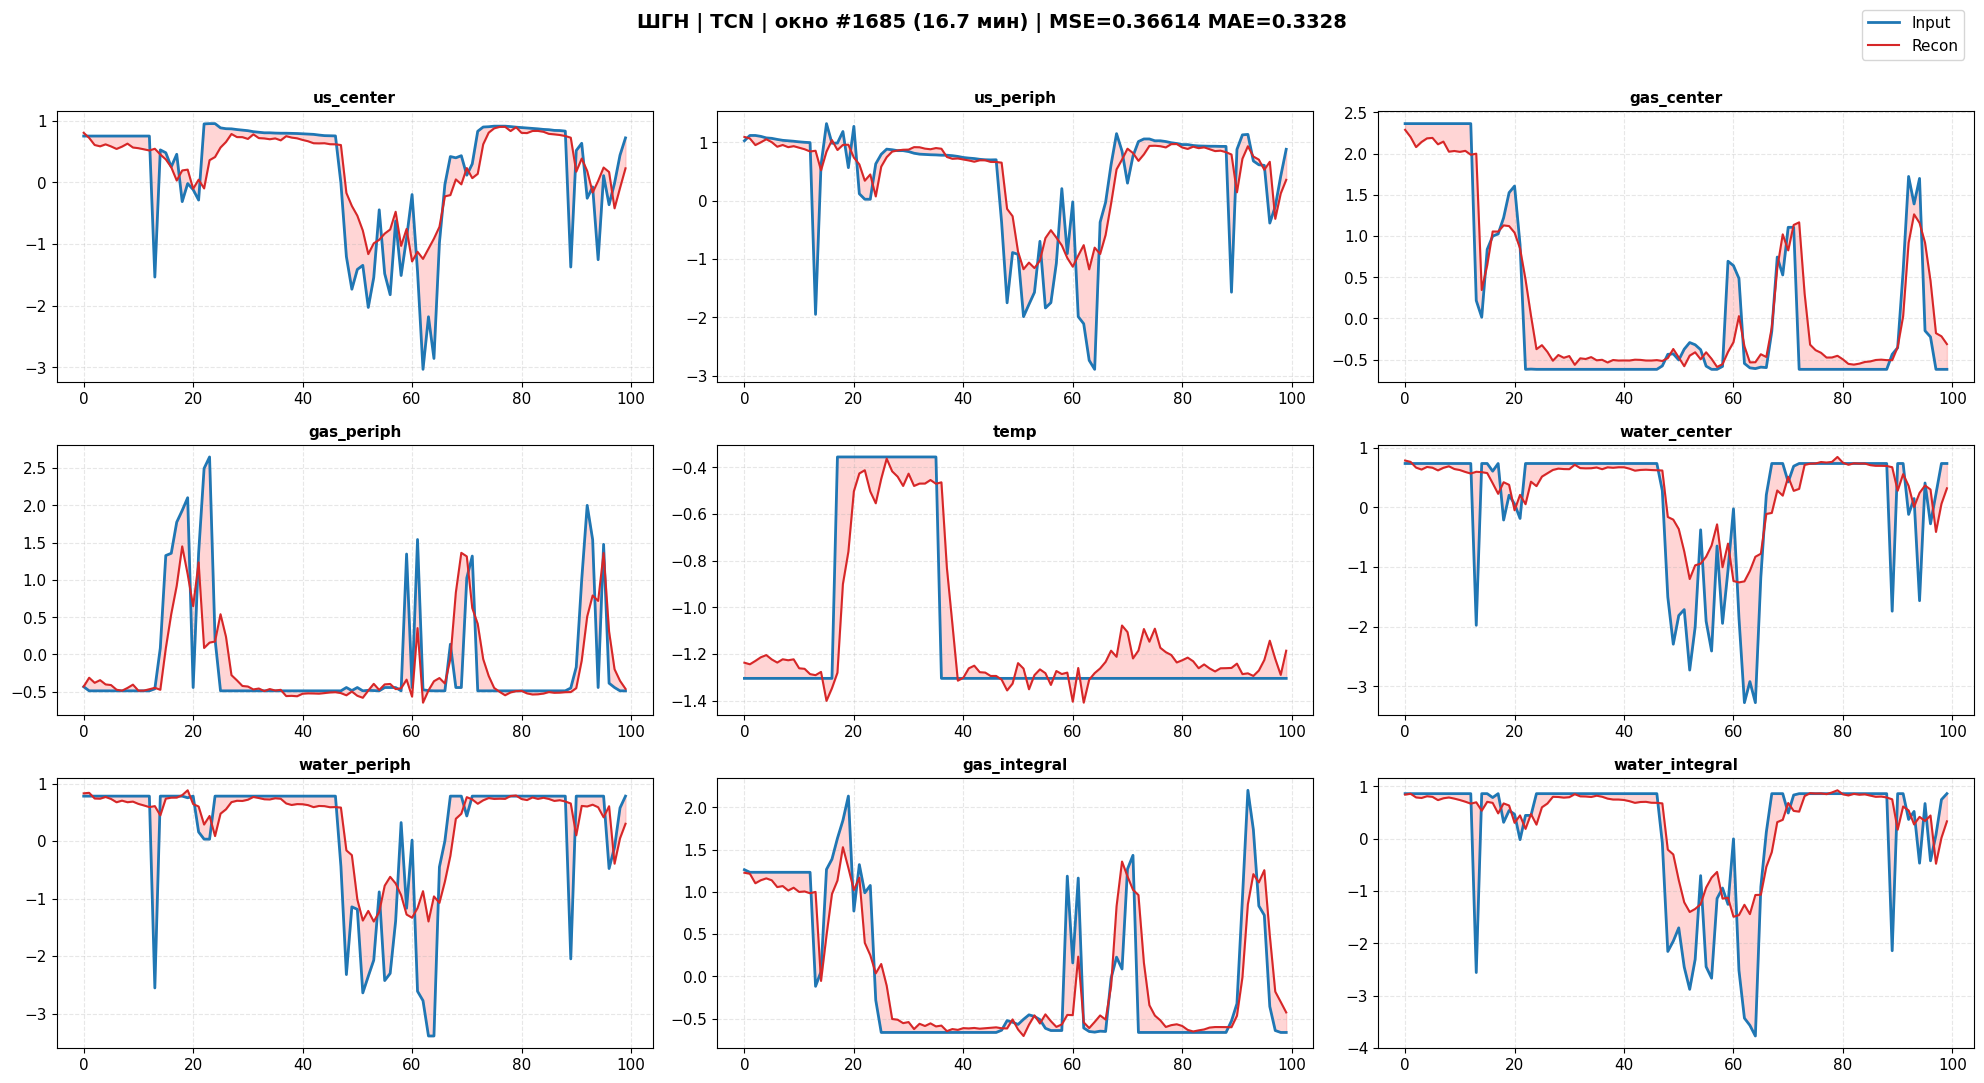

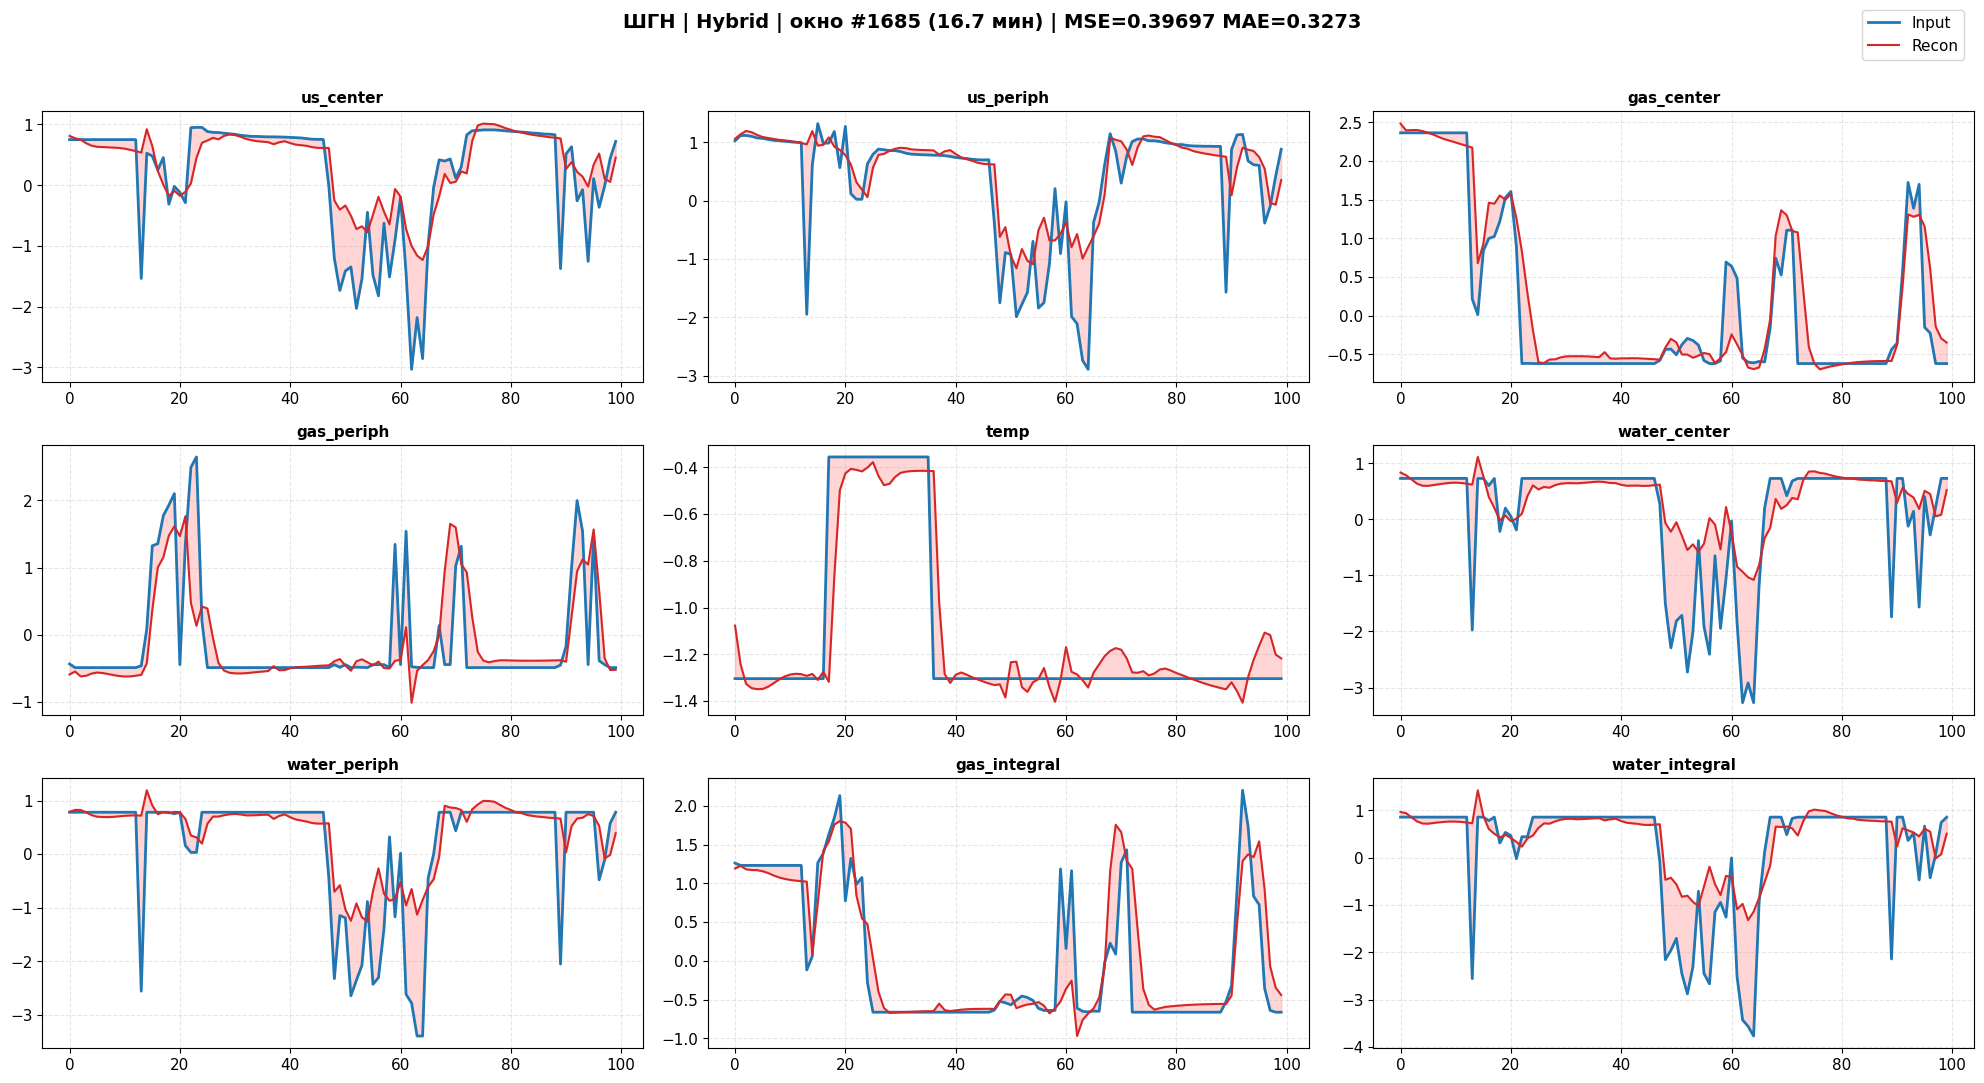

In [41]:
shgn_best_arch: str = min(shgn_results, key=lambda name: shgn_results[name].best.val_loss)
logger.info(f"ШГН: лучшая архитектура → {shgn_best_arch}")
plot_all_reconstructions(shgn_results, X_shgn_val, "ШГН")

# ==== 6. СОХРАНЕНИЕ ЛУЧШИХ МОДЕЛЕЙ ====

In [ ]:
def save_best_model(
    results: dict[str, ArchResult],
    best_arch: str,
    scaler: StandardScaler,
    prefix: str,
    window_size: int,
) -> None:
    model_dir = MODELS_DIR / prefix
    model_dir.mkdir(parents=True, exist_ok=True)

    best = results[best_arch].best

    torch.save(
        {
            "model_state_dict": best.state_dict,
            "architecture": best_arch,
            "latent_dim": best.latent_dim,
            "window_size": window_size,
            "feature_columns": FEATURE_COLUMNS,
            "metrics": {
                "val_loss": best.val_loss,
                "val_mae": best.val_mae,
                "test_loss": best.test_loss,
                "test_mae": best.test_mae,
            },
            "all_results": {
                name: {
                    "best_metrics": {
                        "val_loss": arch_res.best.val_loss,
                        "val_mae": arch_res.best.val_mae,
                        "test_loss": arch_res.best.test_loss,
                        "test_mae": arch_res.best.test_mae,
                    },
                    "best_latent_dim": arch_res.best.latent_dim,
                    "all_dims": [
                        {
                            "latent_dim": r.latent_dim,
                            "val_loss": r.val_loss,
                            "val_mae": r.val_mae,
                            "test_loss": r.test_loss,
                            "test_mae": r.test_mae,
                        }
                        for r in arch_res.all_dims
                    ],
                }
                for name, arch_res in results.items()
            },
        },
        model_dir / "model.pth",
    )

    with open(model_dir / "scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)

    logger.info(f"{prefix.upper()} сохранено → {model_dir.absolute()}")
    logger.info(f"  Архитектура: {best_arch} | latent_dim={best.latent_dim}")
    logger.info(f"  Val  MSE={best.val_loss:.6f} | MAE={best.val_mae:.4f}")
    logger.info(f"  Test MSE={best.test_loss:.6f} | MAE={best.test_mae:.4f}")

In [28]:
save_best_model(ecn_results, ecn_best_arch, scaler_ecn, "ecn", WINDOW_SIZES["ecn"])

2026-02-25 16:28:54,166 - INFO - ECN сохранено → c:\Users\aslan\Рабочий стол\Диплом\code\training\..\models\ecn
2026-02-25 16:28:54,167 - INFO -   Архитектура: GRU | latent_dim=32
2026-02-25 16:28:54,168 - INFO -   Val  MSE=0.023372 | MAE=0.0628
2026-02-25 16:28:54,168 - INFO -   Test MSE=0.026210 | MAE=0.0752


In [42]:
save_best_model(shgn_results, shgn_best_arch, scaler_shgn, "shgn", WINDOW_SIZES["shgn"])

2026-02-25 17:23:13,284 - INFO - SHGN сохранено → c:\Users\aslan\Рабочий стол\Диплом\code\training\..\models\shgn
2026-02-25 17:23:13,286 - INFO -   Архитектура: GRU | latent_dim=32
2026-02-25 17:23:13,286 - INFO -   Val  MSE=0.375717 | MAE=0.5366
2026-02-25 17:23:13,287 - INFO -   Test MSE=0.436236 | MAE=0.6038
